# Modelo de Machine Learning para predecir el abandono de clientes

## Laboratorio completo — Árbol de decisión

**Materia:** Modelos de Machine Learning  
**Producto:** Segundo parcial  
**Tipo de problema:** Clasificación binaria supervisada  
**Algoritmo principal:** Árbol de decisión  
**Estudiante:** Rodolfo Estrada Sánchez  
**Carrera:** Ingeniería en Desarrollo y Gestión de Software  
**Institución:** Universidad Tecnológica del Centro de Veracruz  
**Periodo:** Enero–Abril 2026  

> Este notebook desarrolla un pipeline reproducible desde la obtención y comprensión de los datos hasta la evaluación del modelo y la predicción de un cliente nuevo.

## Índice

1. Planteamiento del problema  
2. Objetivos y decisión ejecutiva  
3. Importación de librerías  
4. Obtención y descripción de los datos  
5. Evaluación de la calidad inicial  
6. Limpieza y preparación  
7. Análisis exploratorio de datos  
8. Separación de variables y prevención de fuga de datos  
9. Pipeline de preprocesamiento  
10. Entrenamiento del árbol de decisión  
11. Optimización de hiperparámetros  
12. Evaluación del modelo  
13. Interpretación del árbol y variables importantes  
14. Predicción con datos nuevos  
15. Guardado del modelo  
16. Conclusiones, limitaciones y recomendaciones

# 1. Planteamiento del problema

Las empresas de telecomunicaciones pierden ingresos cuando sus clientes cancelan los servicios contratados. Si una empresa logra identificar anticipadamente a los clientes con mayor probabilidad de abandono, puede aplicar acciones de retención antes de que ocurra la cancelación.

En este laboratorio se utilizará información demográfica, contractual, económica y de servicios para clasificar a cada cliente en una de dos categorías:

- **No abandona:** el cliente permanece en la empresa.
- **Sí abandona:** el cliente cancela el servicio.

La variable objetivo es `Churn`, por lo que se trata de un problema de **clasificación binaria supervisada**.

# 2. Objetivos y decisión ejecutiva

## Objetivo general

Desarrollar un modelo de clasificación mediante un árbol de decisión que permita predecir si un cliente abandonará una empresa de telecomunicaciones.

## Objetivos específicos

1. Comprender la estructura, variables y calidad inicial del conjunto de datos.
2. Limpiar y transformar la información sin introducir fuga de datos.
3. Identificar patrones relacionados con el abandono de clientes.
4. Entrenar y optimizar un árbol de decisión.
5. Evaluar el modelo mediante accuracy, precision, recall, F1-score, ROC-AUC y matriz de confusión.
6. Realizar una predicción con un cliente nuevo utilizando el mismo pipeline.
7. Formular recomendaciones orientadas a la toma de decisiones.

## Decisión ejecutiva

Los responsables de la empresa podrían utilizar la predicción para priorizar campañas de retención, ofrecer soporte técnico, descuentos, cambios de contrato o atención personalizada a los clientes con mayor riesgo de abandono.

# 3. Importación de librerías

El laboratorio utiliza `pandas` y `numpy` para el manejo de datos, `matplotlib` para visualización y `scikit-learn` para el preprocesamiento, entrenamiento y evaluación.

In [1]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEMILLA = 42

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 4. Obtención y descripción de los datos

Se utiliza el conjunto **Telco Customer Churn**, publicado como ejemplo por IBM. Cada fila representa a un cliente y las columnas describen sus características demográficas, antigüedad, servicios, contrato, método de pago, cargos y condición de abandono.

El código busca primero el archivo `Telco-Customer-Churn.csv` en el directorio actual. Si no existe, intenta descargarlo desde el repositorio público de IBM. Esto permite ejecutar el notebook tanto localmente como en Google Colab.

In [2]:
NOMBRE_ARCHIVO = "Telco-Customer-Churn.csv"
URL_DATOS = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

ruta = Path(NOMBRE_ARCHIVO)

if ruta.exists():
    datos = pd.read_csv(ruta)
    fuente_utilizada = f"Archivo local: {ruta.resolve()}"
else:
    try:
        datos = pd.read_csv(URL_DATOS)
        datos.to_csv(NOMBRE_ARCHIVO, index=False)
        fuente_utilizada = "Repositorio público de IBM"
    except Exception as error:
        raise FileNotFoundError(
            "No se encontró el CSV y tampoco fue posible descargarlo. "
            "Sube Telco-Customer-Churn.csv al entorno y vuelve a ejecutar."
        ) from error

print("Fuente:", fuente_utilizada)
print("Dimensión inicial:", datos.shape)
display(datos.head())

Fuente: Archivo local: /mnt/data/laboratorio_churn_arbol/Telco-Customer-Churn.csv
Dimensión inicial: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


## 4.1 Descripción de variables

- `customerID`: identificador único.
- `gender`: género.
- `SeniorCitizen`: indica si es adulto mayor.
- `Partner`: indica si tiene pareja.
- `Dependents`: indica si tiene dependientes.
- `tenure`: meses de permanencia.
- `PhoneService`: servicio telefónico.
- `MultipleLines`: varias líneas.
- `InternetService`: tipo de internet.
- `OnlineSecurity`: seguridad en línea.
- `OnlineBackup`: respaldo en línea.
- `DeviceProtection`: protección de dispositivos.
- `TechSupport`: soporte técnico.
- `StreamingTV`: televisión por streaming.
- `StreamingMovies`: películas por streaming.
- `Contract`: tipo de contrato.
- `PaperlessBilling`: facturación electrónica.
- `PaymentMethod`: método de pago.
- `MonthlyCharges`: cargo mensual.
- `TotalCharges`: cargos acumulados.
- `Churn`: variable objetivo; indica si el cliente abandonó.

In [3]:
print("Número de registros:", datos.shape[0])
print("Número de columnas:", datos.shape[1])
print("\nNombres de columnas:")
print(datos.columns.tolist())

Número de registros: 7043
Número de columnas: 21

Nombres de columnas:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
resumen_variables = pd.DataFrame({
    "Variable": datos.columns,
    "Tipo": datos.dtypes.astype(str).values,
    "Nulos detectados": datos.isna().sum().values,
    "Valores únicos": datos.nunique(dropna=False).values
})

display(resumen_variables)

,Variable,Tipo,Nulos detectados,Valores únicos
0,customerID,object,0,7043
1,gender,object,0,2
2,SeniorCitizen,int64,0,2
3,Partner,object,0,2
4,Dependents,object,0,2
5,tenure,int64,0,73
6,PhoneService,object,0,2
7,MultipleLines,object,0,3
8,InternetService,object,0,3
9,OnlineSecurity,object,0,3


# 5. Evaluación de la calidad inicial

Se revisan duplicados, valores ausentes, tipos de datos y distribución de la variable objetivo. Aunque `TotalCharges` representa una cantidad, inicialmente aparece como texto porque contiene espacios en algunos registros.

In [5]:
print("Registros duplicados:", datos.duplicated().sum())
print("\nValores nulos detectados inicialmente:")
display(datos.isna().sum().to_frame("Nulos"))

print("\nDistribución inicial de Churn:")
display(datos["Churn"].value_counts().to_frame("Frecuencia"))
display((datos["Churn"].value_counts(normalize=True) * 100).round(2).to_frame("Porcentaje"))

Registros duplicados: 0

Valores nulos detectados inicialmente:


,Nulos
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Distribución inicial de Churn:


,Frecuencia
Churn,
No,5174
Yes,1869


,Porcentaje
Churn,
No,73.4600
Yes,26.5400


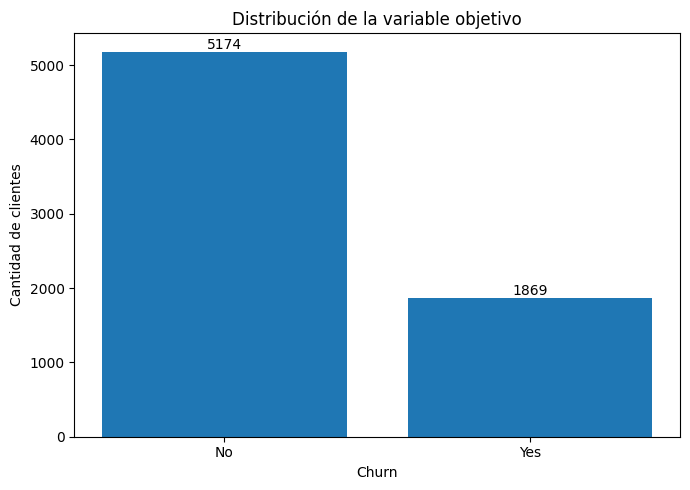

In [6]:
valores_churn = datos["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(valores_churn.index, valores_churn.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

for i, valor in enumerate(valores_churn.values):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Interpretación

La clase `No` es mayoritaria. Por ello, la exactitud no será suficiente para evaluar el desempeño. También se utilizarán precision, recall, F1-score, ROC-AUC y matriz de confusión. El **recall de la clase de abandono** será especialmente importante, porque mide qué proporción de clientes que realmente abandonan son identificados por el modelo.

# 6. Limpieza y preparación

Las decisiones aplicadas son:

1. Convertir `TotalCharges` a formato numérico.
2. Convertir valores inválidos en ausentes.
3. Eliminar los pocos registros sin `TotalCharges`.
4. Eliminar duplicados.
5. Conservar una copia limpia para el análisis.
6. Excluir `customerID` del entrenamiento, porque solo es un identificador y no aporta un patrón generalizable.

In [7]:
datos_limpios = datos.copy()

datos_limpios["TotalCharges"] = pd.to_numeric(
    datos_limpios["TotalCharges"],
    errors="coerce"
)

nulos_total_charges = datos_limpios["TotalCharges"].isna().sum()
duplicados = datos_limpios.duplicated().sum()
registros_antes = len(datos_limpios)

datos_limpios = (
    datos_limpios
    .drop_duplicates()
    .dropna(subset=["TotalCharges"])
    .reset_index(drop=True)
)

registros_despues = len(datos_limpios)

print("Nulos detectados en TotalCharges:", nulos_total_charges)
print("Duplicados detectados:", duplicados)
print("Registros antes:", registros_antes)
print("Registros después:", registros_despues)
print("Registros eliminados:", registros_antes - registros_despues)
print("Nulos restantes:", datos_limpios.isna().sum().sum())

Nulos detectados en TotalCharges: 11
Duplicados detectados: 0
Registros antes: 7043
Registros después: 7032
Registros eliminados: 11
Nulos restantes: 0


In [8]:
display(datos_limpios.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,032.0000",NaN,NaN,NaN,0.1624,0.3688,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,032.0000",NaN,NaN,NaN,32.4218,24.5453,1.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Justificación de la limpieza

Los registros sin `TotalCharges` representan una proporción muy pequeña del dataset y no contienen un valor económico válido para esa variable. Se eliminan para conservar consistencia. No se aplica escalado porque los árboles de decisión dividen los datos mediante umbrales y no dependen de distancias ni de la escala de las variables.

# 7. Análisis exploratorio de datos

El EDA busca identificar patrones, distribuciones y relaciones útiles para explicar el abandono.

In [9]:
tabla_objetivo = pd.DataFrame({
    "Frecuencia": datos_limpios["Churn"].value_counts(),
    "Porcentaje": datos_limpios["Churn"].value_counts(normalize=True) * 100
})
display(tabla_objetivo.round(2))

,Frecuencia,Porcentaje
Churn,,
No,5163,73.4200
Yes,1869,26.5800


## 7.1 Abandono según el tipo de contrato

Churn,No,Yes
Contract,,
Month-to-month,57.2900,42.7100
One year,88.7200,11.2800
Two year,97.1500,2.8500


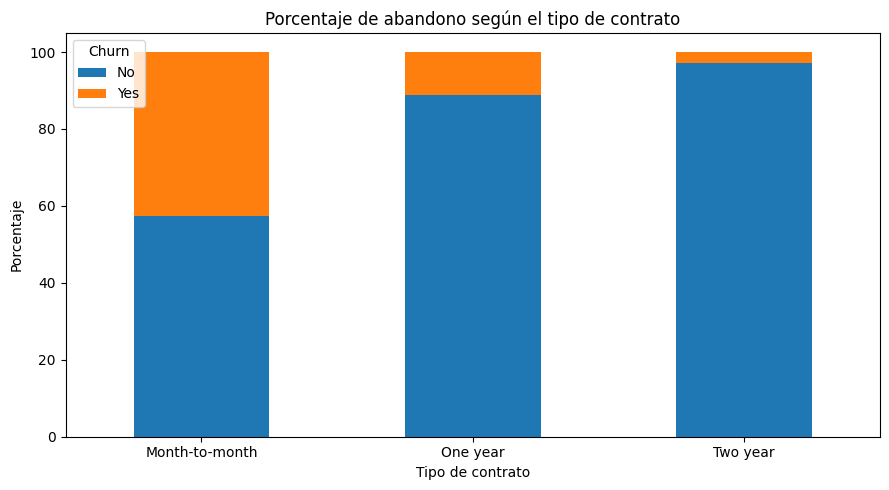

In [10]:
contrato_churn = pd.crosstab(
    datos_limpios["Contract"],
    datos_limpios["Churn"],
    normalize="index"
) * 100

display(contrato_churn.round(2))

contrato_churn.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Porcentaje de abandono según el tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Interpretación

La comparación permite identificar si los contratos de menor duración concentran una mayor proporción de abandono. Este hallazgo es útil porque la empresa podría incentivar contratos de mayor plazo entre clientes vulnerables.

## 7.2 Abandono según el servicio de internet

Churn,No,Yes
InternetService,,
DSL,81.0000,19.0000
Fiber optic,58.1100,41.8900
No,92.5700,7.4300


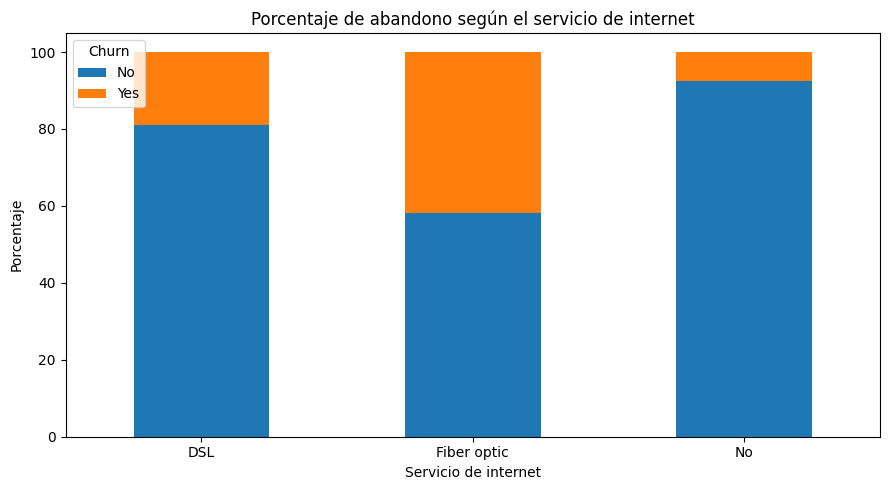

In [11]:
internet_churn = pd.crosstab(
    datos_limpios["InternetService"],
    datos_limpios["Churn"],
    normalize="index"
) * 100

display(internet_churn.round(2))

internet_churn.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Porcentaje de abandono según el servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

## 7.3 Abandono según soporte técnico

Churn,No,Yes
TechSupport,,
No,58.3500,41.6500
No internet service,92.5700,7.4300
Yes,84.8000,15.2000


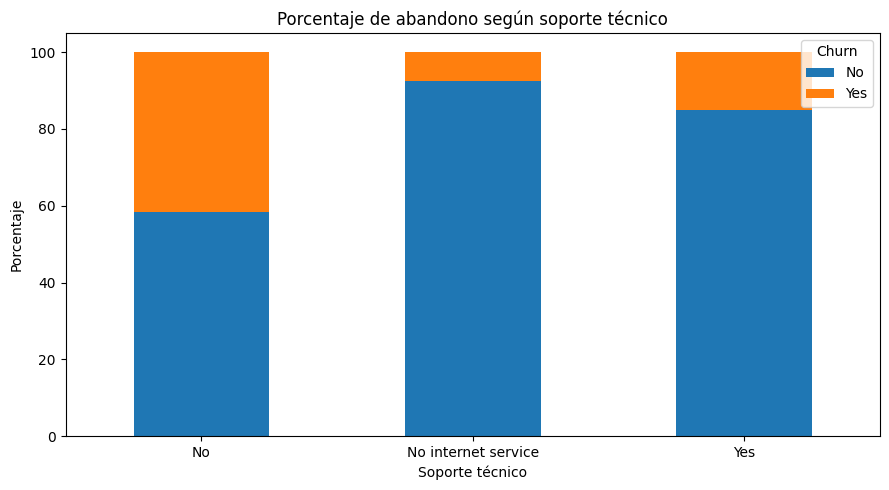

In [12]:
soporte_churn = pd.crosstab(
    datos_limpios["TechSupport"],
    datos_limpios["Churn"],
    normalize="index"
) * 100

display(soporte_churn.round(2))

soporte_churn.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Porcentaje de abandono según soporte técnico")
plt.xlabel("Soporte técnico")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

## 7.4 Abandono según método de pago

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.2700,16.7300
Credit card (automatic),84.7500,15.2500
Electronic check,54.7100,45.2900
Mailed check,80.8000,19.2000


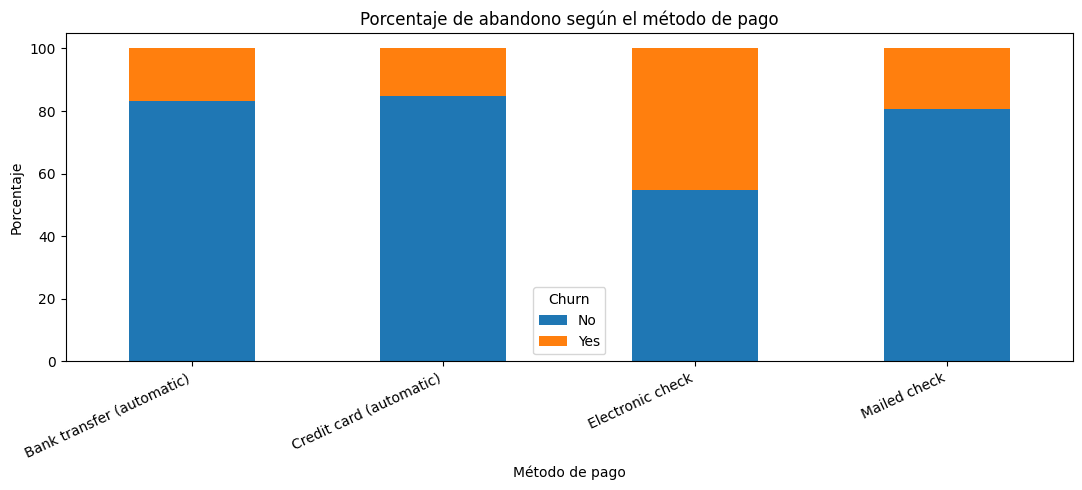

In [13]:
pago_churn = pd.crosstab(
    datos_limpios["PaymentMethod"],
    datos_limpios["Churn"],
    normalize="index"
) * 100

display(pago_churn.round(2))

pago_churn.plot(kind="bar", stacked=True, figsize=(11, 5))
plt.title("Porcentaje de abandono según el método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Porcentaje")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

## 7.5 Cargos mensuales y abandono

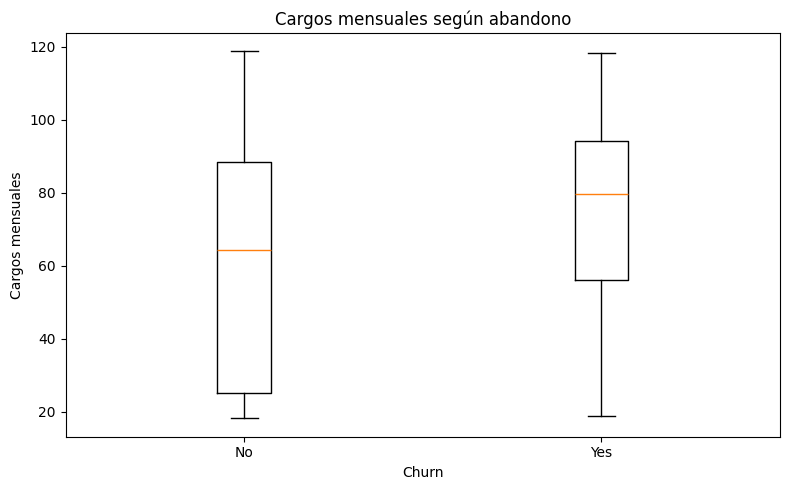

,count,mean,median,std
Churn,,,,
No,5163,61.3100,64.4500,31.0900
Yes,1869,74.4400,79.6500,24.6700


In [14]:
grupos_cargos = [
    datos_limpios.loc[datos_limpios["Churn"] == "No", "MonthlyCharges"],
    datos_limpios.loc[datos_limpios["Churn"] == "Yes", "MonthlyCharges"]
]

plt.figure(figsize=(8, 5))
plt.boxplot(grupos_cargos, tick_labels=["No", "Yes"])
plt.title("Cargos mensuales según abandono")
plt.xlabel("Churn")
plt.ylabel("Cargos mensuales")
plt.tight_layout()
plt.show()

display(
    datos_limpios.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

## 7.6 Antigüedad y abandono

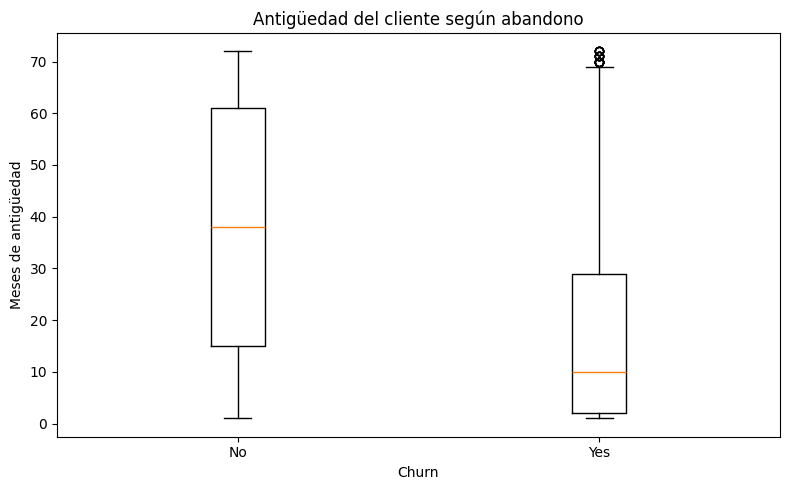

,count,mean,median,std
Churn,,,,
No,5163,37.6500,38.0000,24.0800
Yes,1869,17.9800,10.0000,19.5300


In [15]:
grupos_antiguedad = [
    datos_limpios.loc[datos_limpios["Churn"] == "No", "tenure"],
    datos_limpios.loc[datos_limpios["Churn"] == "Yes", "tenure"]
]

plt.figure(figsize=(8, 5))
plt.boxplot(grupos_antiguedad, tick_labels=["No", "Yes"])
plt.title("Antigüedad del cliente según abandono")
plt.xlabel("Churn")
plt.ylabel("Meses de antigüedad")
plt.tight_layout()
plt.show()

display(
    datos_limpios.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

## 7.7 Relación entre variables numéricas

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.0000,0.0160,0.2200,0.1020
tenure,0.0160,1.0000,0.2470,0.8260
MonthlyCharges,0.2200,0.2470,1.0000,0.6510
TotalCharges,0.1020,0.8260,0.6510,1.0000


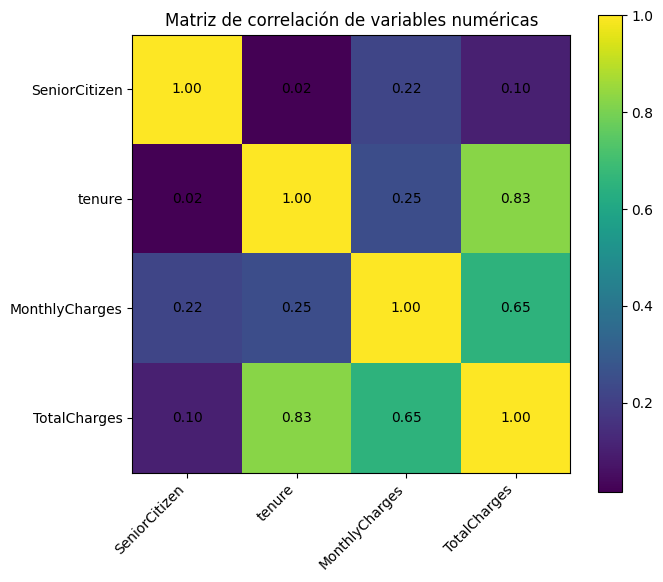

In [16]:
variables_numericas_eda = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlaciones = datos_limpios[variables_numericas_eda].corr()
display(correlaciones.round(3))

plt.figure(figsize=(7, 6))
imagen = plt.imshow(correlaciones)
plt.colorbar(imagen)
plt.xticks(range(len(variables_numericas_eda)), variables_numericas_eda, rotation=45, ha="right")
plt.yticks(range(len(variables_numericas_eda)), variables_numericas_eda)
plt.title("Matriz de correlación de variables numéricas")

for i in range(len(variables_numericas_eda)):
    for j in range(len(variables_numericas_eda)):
        plt.text(j, i, f"{correlaciones.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 7.8 Resumen automático de hallazgos del EDA

In [17]:
tasa_general = datos_limpios["Churn"].eq("Yes").mean() * 100

tasa_contrato = (
    datos_limpios.assign(Abandono=datos_limpios["Churn"].eq("Yes").astype(int))
    .groupby("Contract")["Abandono"]
    .mean()
    .sort_values(ascending=False) * 100
)

tasa_internet = (
    datos_limpios.assign(Abandono=datos_limpios["Churn"].eq("Yes").astype(int))
    .groupby("InternetService")["Abandono"]
    .mean()
    .sort_values(ascending=False) * 100
)

tasa_soporte = (
    datos_limpios.assign(Abandono=datos_limpios["Churn"].eq("Yes").astype(int))
    .groupby("TechSupport")["Abandono"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(f"Tasa general de abandono: {tasa_general:.2f}%")
print("\nTasa de abandono por contrato:")
print(tasa_contrato.round(2))
print("\nTasa de abandono por servicio de internet:")
print(tasa_internet.round(2))
print("\nTasa de abandono por soporte técnico:")
print(tasa_soporte.round(2))

Tasa general de abandono: 26.58%

Tasa de abandono por contrato:
Contract
Month-to-month   42.7100
One year         11.2800
Two year          2.8500
Name: Abandono, dtype: float64

Tasa de abandono por servicio de internet:
InternetService
Fiber optic   41.8900
DSL           19.0000
No             7.4300
Name: Abandono, dtype: float64

Tasa de abandono por soporte técnico:
TechSupport
No                    41.6500
Yes                   15.2000
No internet service    7.4300
Name: Abandono, dtype: float64


# 8. Separación de variables y prevención de fuga de datos

La variable objetivo se convierte a formato binario:

- `0`: permanece.
- `1`: abandona.

La división entrenamiento/prueba se realiza **antes** de ajustar las transformaciones. El `ColumnTransformer` y el `Pipeline` garantizan que los codificadores e imputadores se ajusten únicamente con los datos de entrenamiento.

In [18]:
X = datos_limpios.drop(columns=["customerID", "Churn"]).copy()
y = datos_limpios["Churn"].map({"No": 0, "Yes": 1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de y_train:")
display((y_train.value_counts(normalize=True) * 100).round(2).to_frame("Porcentaje"))

print("\nDistribución de y_test:")
display((y_test.value_counts(normalize=True) * 100).round(2).to_frame("Porcentaje"))

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)

Distribución de y_train:


,Porcentaje
Churn,
0,73.4200
1,26.5800



Distribución de y_test:


,Porcentaje
Churn,
0,73.4200
1,26.5800


# 9. Pipeline de preprocesamiento

Las variables categóricas se imputan con la moda y se convierten mediante `OneHotEncoder`. Las numéricas se imputan con la mediana. El procesamiento se integra con el modelo para que las mismas transformaciones se apliquen al entrenamiento, evaluación y predicción nueva.

In [19]:
columnas_categoricas = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

columnas_numericas = X.select_dtypes(
    exclude=["object", "category", "bool"]
).columns.tolist()

print("Variables categóricas:", len(columnas_categoricas))
print(columnas_categoricas)
print("\nVariables numéricas:", len(columnas_numericas))
print(columnas_numericas)

Variables categóricas: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variables numéricas: 4
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
pipeline_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore"))
])

pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median"))
])

preprocesador = ColumnTransformer(
    transformers=[
        ("categoricas", pipeline_categorico, columnas_categoricas),
        ("numericas", pipeline_numerico, columnas_numericas)
    ]
)

pipeline_arbol = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(random_state=SEMILLA))
])

print("Pipeline creado correctamente.")

Pipeline creado correctamente.


# 10. Entrenamiento del árbol de decisión inicial

Primero se entrena un árbol sin poda para obtener una línea base. Un árbol sin restricciones puede memorizar patrones del entrenamiento y sobreajustarse, por lo que después se optimizarán sus hiperparámetros.

In [21]:
modelo_inicial = pipeline_arbol.fit(X_train, y_train)

pred_inicial = modelo_inicial.predict(X_test)
prob_inicial = modelo_inicial.predict_proba(X_test)[:, 1]

metricas_iniciales = {
    "Accuracy": accuracy_score(y_test, pred_inicial),
    "Precision": precision_score(y_test, pred_inicial),
    "Recall": recall_score(y_test, pred_inicial),
    "F1-score": f1_score(y_test, pred_inicial),
    "ROC-AUC": roc_auc_score(y_test, prob_inicial)
}

display(pd.DataFrame(metricas_iniciales, index=["Árbol inicial"]).T)

,Árbol inicial
Accuracy,0.7221
Precision,0.4780
Recall,0.4947
F1-score,0.4862
ROC-AUC,0.6498


# 11. Optimización de hiperparámetros

Se utiliza `GridSearchCV` con validación cruzada de cinco particiones. La métrica de selección es F1-score, porque combina precision y recall y resulta más informativa que la exactitud ante el desbalance de clases.

Hiperparámetros evaluados:

- `criterion`: medida para seleccionar divisiones.
- `max_depth`: profundidad máxima.
- `min_samples_leaf`: mínimo de registros por hoja.
- `class_weight`: ponderación de clases.

In [22]:
rejilla_parametros = {
    "modelo__criterion": ["gini", "entropy"],
    "modelo__max_depth": [4, 6, 8],
    "modelo__min_samples_leaf": [5, 10],
    "modelo__class_weight": [None, "balanced"]
}

busqueda = GridSearchCV(
    estimator=pipeline_arbol,
    param_grid=rejilla_parametros,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

busqueda.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(busqueda.best_params_)
print(f"\nMejor F1 promedio en validación cruzada: {busqueda.best_score_:.4f}")

Mejores hiperparámetros:
{'modelo__class_weight': 'balanced', 'modelo__criterion': 'gini', 'modelo__max_depth': 4, 'modelo__min_samples_leaf': 5}

Mejor F1 promedio en validación cruzada: 0.6162


In [23]:
resultados_cv = pd.DataFrame(busqueda.cv_results_)

# Compatibilidad con distintas versiones de scikit-learn:
# se detectan automáticamente las columnas de parámetros.
columnas_parametros = [
    columna for columna in resultados_cv.columns
    if str(columna).startswith("param_")
]

columnas_resultado = [
    "rank_test_score",
    "mean_train_score",
    "mean_test_score"
] + columnas_parametros

display(
    resultados_cv[columnas_resultado]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

,rank_test_score,mean_train_score,mean_test_score,param_modelo__class_weight,param_modelo__criterion,param_modelo__max_depth,param_modelo__min_samples_leaf
0,1,0.6295,0.6162,balanced,gini,4,5
1,1,0.6295,0.6162,balanced,gini,4,10
2,3,0.6290,0.6151,balanced,entropy,4,5
3,3,0.6290,0.6151,balanced,entropy,4,10
4,5,0.6560,0.6133,balanced,entropy,6,10
5,6,0.6590,0.6120,balanced,gini,6,10
6,7,0.6544,0.6093,balanced,entropy,6,5
7,8,0.6596,0.6076,balanced,gini,6,5
8,9,0.6850,0.6039,balanced,entropy,8,10
9,10,0.6871,0.6022,balanced,gini,8,10


# 12. Evaluación del modelo optimizado

In [24]:
modelo_final = busqueda.best_estimator_

pred_final = modelo_final.predict(X_test)
prob_final = modelo_final.predict_proba(X_test)[:, 1]

metricas_finales = {
    "Accuracy": accuracy_score(y_test, pred_final),
    "Precision": precision_score(y_test, pred_final),
    "Recall": recall_score(y_test, pred_final),
    "F1-score": f1_score(y_test, pred_final),
    "ROC-AUC": roc_auc_score(y_test, prob_final)
}

comparacion_metricas = pd.DataFrame({
    "Árbol inicial": metricas_iniciales,
    "Árbol optimizado": metricas_finales
}).T

display(comparacion_metricas.round(4))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Árbol inicial,0.7221,0.4780,0.4947,0.4862,0.6498
Árbol optimizado,0.7065,0.4697,0.8075,0.5939,0.8229


In [25]:
print("Reporte de clasificación del modelo optimizado:\n")
print(
    classification_report(
        y_test,
        pred_final,
        target_names=["Permanece", "Abandona"],
        digits=4
    )
)

Reporte de clasificación del modelo optimizado:

              precision    recall  f1-score   support

   Permanece     0.9058    0.6699    0.7702      1033
    Abandona     0.4697    0.8075    0.5939       374

    accuracy                         0.7065      1407
   macro avg     0.6877    0.7387    0.6820      1407
weighted avg     0.7898    0.7065    0.7233      1407



## 12.1 Matriz de confusión

La matriz permite identificar:

- Verdaderos negativos: permanecen y el modelo lo predice correctamente.
- Falsos positivos: permanecen, pero el modelo los marca como riesgo.
- Falsos negativos: abandonan, pero el modelo no los detecta.
- Verdaderos positivos: abandonan y el modelo los identifica correctamente.

,Predice: permanece,Predice: abandona
Real: permanece,692,341
Real: abandona,72,302


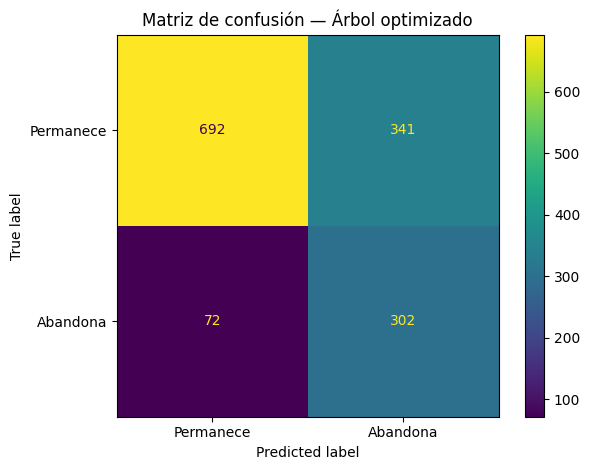

In [26]:
matriz = confusion_matrix(y_test, pred_final)
display(pd.DataFrame(
    matriz,
    index=["Real: permanece", "Real: abandona"],
    columns=["Predice: permanece", "Predice: abandona"]
))

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Permanece", "Abandona"]
).plot()

plt.title("Matriz de confusión — Árbol optimizado")
plt.tight_layout()
plt.show()

## 12.2 Curva ROC

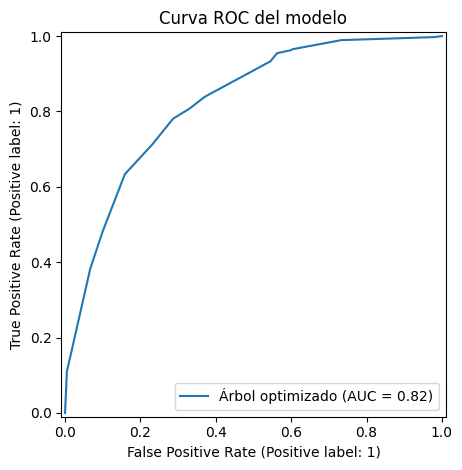

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    prob_final,
    name="Árbol optimizado"
)

plt.title("Curva ROC del modelo")
plt.tight_layout()
plt.show()

## 12.3 Interpretación ejecutiva de métricas

In [28]:
tn, fp, fn, tp = matriz.ravel()

print(f"Accuracy: {metricas_finales['Accuracy']:.2%}")
print(f"Precision: {metricas_finales['Precision']:.2%}")
print(f"Recall: {metricas_finales['Recall']:.2%}")
print(f"F1-score: {metricas_finales['F1-score']:.2%}")
print(f"ROC-AUC: {metricas_finales['ROC-AUC']:.4f}")
print()
print(f"Clientes que abandonaron y fueron detectados: {tp}")
print(f"Clientes que abandonaron y no fueron detectados: {fn}")
print(f"Clientes marcados como riesgo sin abandonar: {fp}")
print(f"Clientes que permanecieron y fueron clasificados correctamente: {tn}")
print()
print(
    "Interpretación: el recall indica la proporción de clientes que realmente "
    "abandonaron y fueron identificados. Los falsos positivos representan "
    "clientes que podrían recibir una acción de retención aunque finalmente "
    "no abandonaran."
)

Accuracy: 70.65%
Precision: 46.97%
Recall: 80.75%
F1-score: 59.39%
ROC-AUC: 0.8229

Clientes que abandonaron y fueron detectados: 302
Clientes que abandonaron y no fueron detectados: 72
Clientes marcados como riesgo sin abandonar: 341
Clientes que permanecieron y fueron clasificados correctamente: 692

Interpretación: el recall indica la proporción de clientes que realmente abandonaron y fueron identificados. Los falsos positivos representan clientes que podrían recibir una acción de retención aunque finalmente no abandonaran.


# 13. Interpretación del árbol y variables importantes

Los árboles de decisión permiten conocer qué variables tuvieron mayor participación en las divisiones. La importancia no demuestra causalidad; únicamente representa utilidad predictiva dentro de este modelo y dataset.

In [29]:
preprocesador_ajustado = modelo_final.named_steps["preprocesamiento"]
arbol_ajustado = modelo_final.named_steps["modelo"]

nombres_variables = preprocesador_ajustado.get_feature_names_out()
importancias = arbol_ajustado.feature_importances_

tabla_importancias = (
    pd.DataFrame({
        "Variable": nombres_variables,
        "Importancia": importancias
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

display(tabla_importancias.head(15))

,Variable,Importancia
0,categoricas__Contract_Month-to-month,0.6584
1,categoricas__InternetService_Fiber optic,0.1055
2,numericas__tenure,0.1008
3,numericas__MonthlyCharges,0.0409
4,categoricas__PaymentMethod_Electronic check,0.0238
5,categoricas__TechSupport_No,0.0196
6,categoricas__Contract_Two year,0.0149
7,numericas__TotalCharges,0.0122
8,categoricas__Contract_One year,0.0109
9,categoricas__StreamingMovies_Yes,0.0086


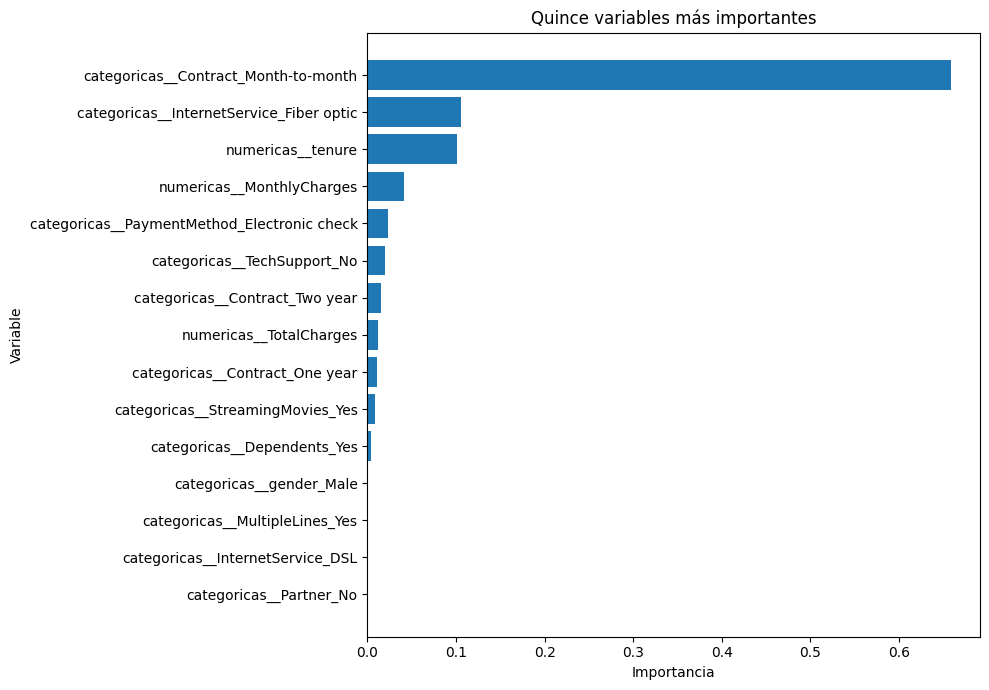

In [30]:
top_importancias = tabla_importancias.head(15).sort_values("Importancia")

plt.figure(figsize=(10, 7))
plt.barh(top_importancias["Variable"], top_importancias["Importancia"])
plt.title("Quince variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 13.1 Visualización parcial del árbol

Para conservar legibilidad se muestran únicamente los primeros niveles. El modelo completo puede contener más nodos.

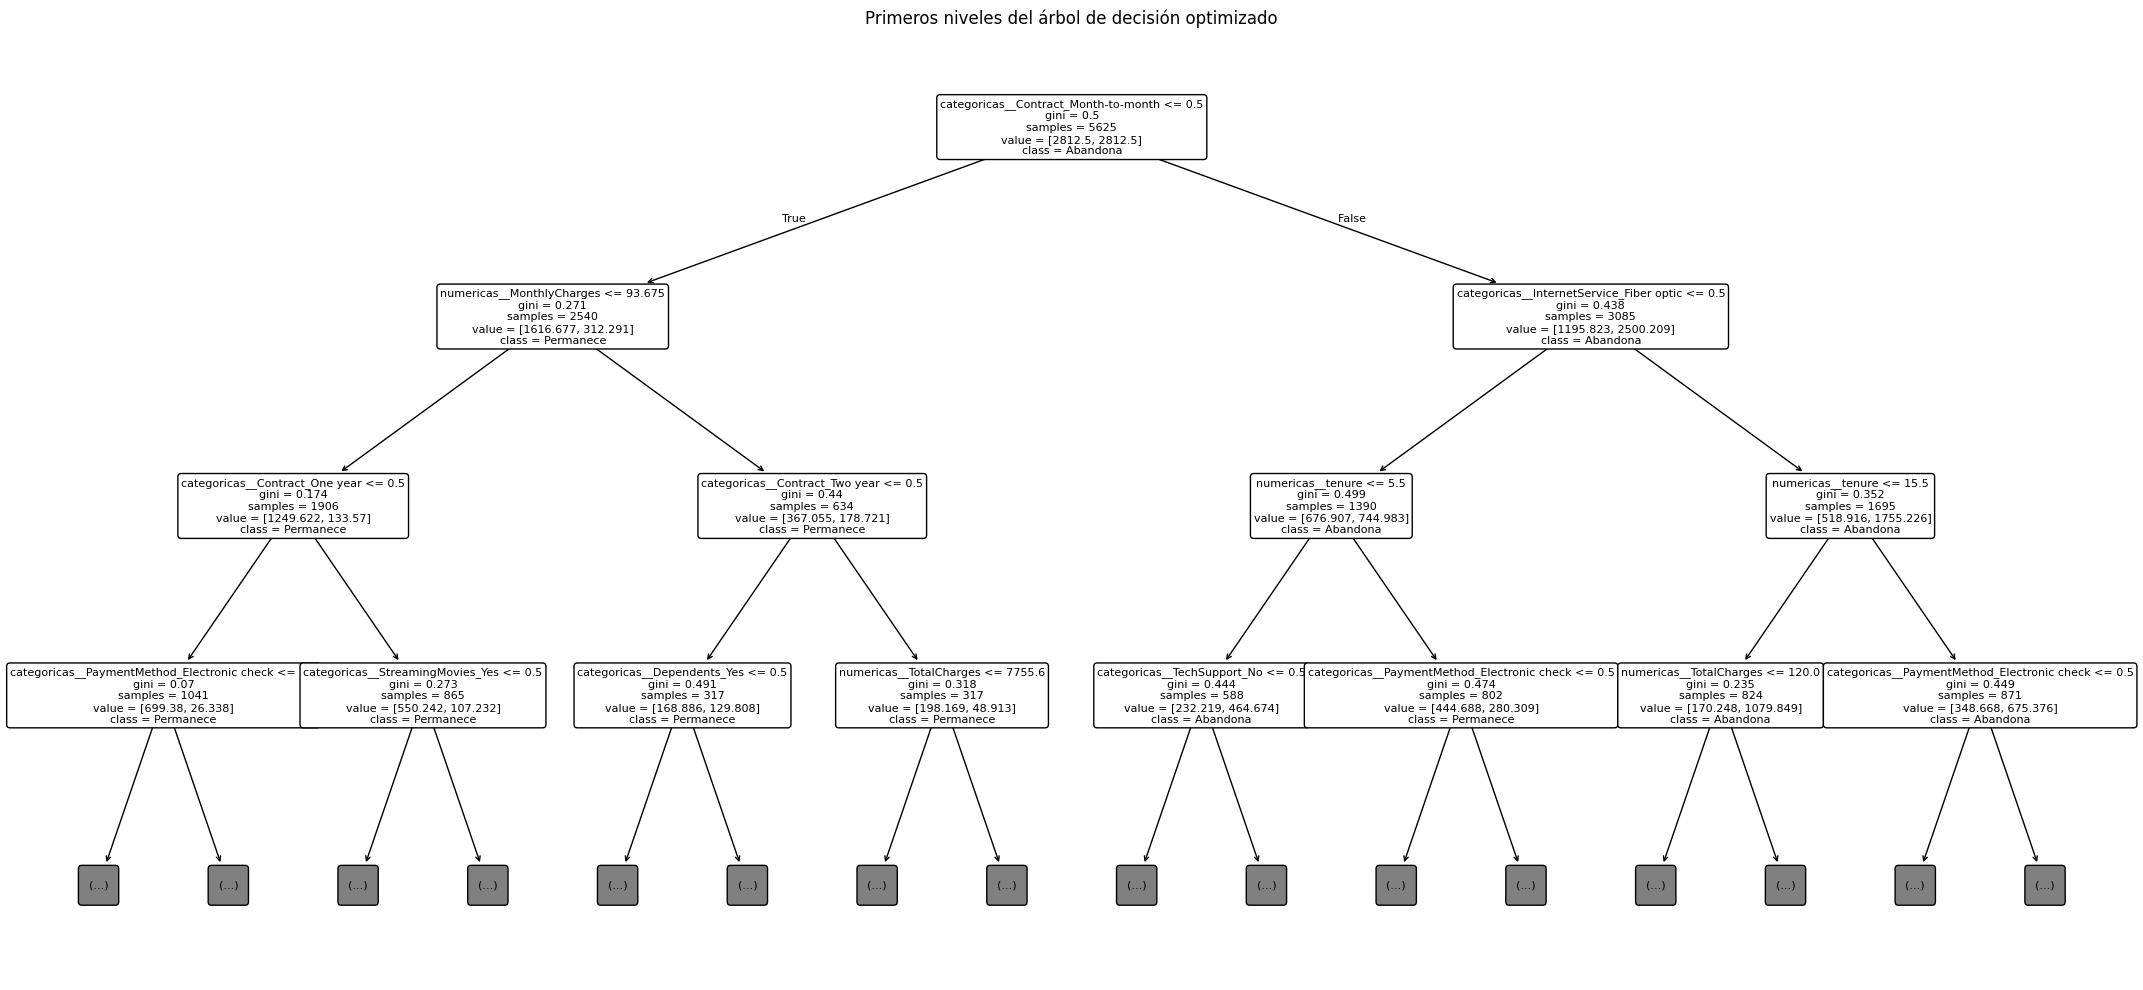

In [31]:
plt.figure(figsize=(22, 10))

plot_tree(
    arbol_ajustado,
    feature_names=nombres_variables,
    class_names=["Permanece", "Abandona"],
    max_depth=3,
    filled=False,
    rounded=True,
    fontsize=8
)

plt.title("Primeros niveles del árbol de decisión optimizado")
plt.tight_layout()
plt.show()

In [32]:
reglas_resumidas = export_text(
    arbol_ajustado,
    feature_names=list(nombres_variables),
    max_depth=3
)

print("Reglas resumidas de los primeros niveles:\n")
print(reglas_resumidas)

Reglas resumidas de los primeros niveles:

|--- categoricas__Contract_Month-to-month <= 0.50
|   |--- numericas__MonthlyCharges <= 93.67
|   |   |--- categoricas__Contract_One year <= 0.50
|   |   |   |--- categoricas__PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- categoricas__PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- class: 0
|   |   |--- categoricas__Contract_One year >  0.50
|   |   |   |--- categoricas__StreamingMovies_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- categoricas__StreamingMovies_Yes >  0.50
|   |   |   |   |--- class: 0
|   |--- numericas__MonthlyCharges >  93.67
|   |   |--- categoricas__Contract_Two year <= 0.50
|   |   |   |--- categoricas__Dependents_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- categoricas__Dependents_Yes >  0.50
|   |   |   |   |--- class: 0
|   |   |--- categoricas__Contract_Two year >  0.50
|   |   |   |--- numericas__TotalCharges <= 7755.60
|   |   |   |   |--

# 14. Predicción con datos nuevos

El nuevo cliente debe incluir las mismas variables de entrada utilizadas durante el entrenamiento. No es necesario codificar manualmente las categorías porque el pipeline aplica automáticamente el preprocesamiento.

In [33]:
nuevo_cliente = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 4,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 382.00
}])

display(nuevo_cliente)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,4,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.5000,382.0000


In [34]:
prediccion_nueva = modelo_final.predict(nuevo_cliente)[0]
probabilidad_nueva = modelo_final.predict_proba(nuevo_cliente)[0, 1]

etiqueta = "Sí abandonará" if prediccion_nueva == 1 else "No abandonará"

print("Resultado de la predicción:", etiqueta)
print(f"Probabilidad estimada de abandono: {probabilidad_nueva:.2%}")

if prediccion_nueva == 1:
    print(
        "\nRecomendación: priorizar al cliente para una campaña de retención, "
        "revisar la calidad del servicio, ofrecer soporte técnico y evaluar "
        "un incentivo para migrar a un contrato de mayor duración."
    )
else:
    print(
        "\nRecomendación: mantener seguimiento normal y continuar ofreciendo "
        "una experiencia de servicio estable."
    )

Resultado de la predicción: Sí abandonará
Probabilidad estimada de abandono: 83.52%

Recomendación: priorizar al cliente para una campaña de retención, revisar la calidad del servicio, ofrecer soporte técnico y evaluar un incentivo para migrar a un contrato de mayor duración.


### Significado de la predicción nueva

La salida representa una estimación basada en patrones históricos. No debe interpretarse como certeza ni como causa del abandono. La predicción sirve para priorizar acciones comerciales, pero la decisión final debe complementarse con información actual del cliente y criterios humanos.

# 15. Guardado del modelo

Se guarda el pipeline completo, incluyendo imputación, codificación y árbol de decisión. De esta manera, las predicciones futuras conservarán exactamente el mismo preprocesamiento.

In [35]:
RUTA_MODELO = "modelo_churn_arbol_decision.joblib"
joblib.dump(modelo_final, RUTA_MODELO)

print("Modelo guardado en:", RUTA_MODELO)
print("Tamaño del archivo:", os.path.getsize(RUTA_MODELO), "bytes")

Modelo guardado en: modelo_churn_arbol_decision.joblib
Tamaño del archivo: 10644 bytes


In [36]:
modelo_recargado = joblib.load(RUTA_MODELO)

prediccion_recargada = modelo_recargado.predict(nuevo_cliente)[0]
probabilidad_recargada = modelo_recargado.predict_proba(nuevo_cliente)[0, 1]

print("Predicción con modelo recargado:", prediccion_recargada)
print(f"Probabilidad con modelo recargado: {probabilidad_recargada:.4f}")

Predicción con modelo recargado: 1
Probabilidad con modelo recargado: 0.8352


# 16. Conclusiones, limitaciones y recomendaciones

In [37]:
mejores_variables = ", ".join(tabla_importancias.head(5)["Variable"].tolist())

conclusion = f"""
CONCLUSIONES

1. Se desarrolló un pipeline reproducible de clasificación binaria utilizando
   un árbol de decisión y preprocesamiento automático.

2. El modelo optimizado obtuvo:
   - Accuracy: {metricas_finales['Accuracy']:.2%}
   - Precision: {metricas_finales['Precision']:.2%}
   - Recall: {metricas_finales['Recall']:.2%}
   - F1-score: {metricas_finales['F1-score']:.2%}
   - ROC-AUC: {metricas_finales['ROC-AUC']:.4f}

3. El recall muestra que el modelo detecta una proporción relevante de los
   clientes que realmente abandonan. Esta característica es útil cuando el
   costo de no detectar un abandono es mayor que el costo de contactar a un
   cliente que finalmente permanecerá.

4. Entre las variables con mayor importancia predictiva se encuentran:
   {mejores_variables}.

5. La predicción nueva se realizó con el mismo pipeline, lo que garantiza
   trazabilidad y consistencia del preprocesamiento.

RECOMENDACIONES

- Priorizar campañas de bajo costo para clientes clasificados como riesgo.
- Promover contratos de mayor duración cuando sea comercialmente viable.
- Revisar soporte técnico, calidad del servicio y experiencia de pago.
- Complementar la predicción con valor económico del cliente.
- Medir el resultado real de las acciones de retención.

LIMITACIONES Y RIESGOS

- El dataset representa una empresa ficticia y puede no reflejar otra empresa.
- La importancia de variables no demuestra causalidad.
- El modelo puede producir falsos positivos y falsos negativos.
- Los patrones pueden cambiar con el tiempo.
- Antes de usarlo en producción se requieren datos actuales, validación,
  monitoreo, revisión de sesgos y criterios de protección de datos.
"""

print(conclusion)


CONCLUSIONES

1. Se desarrolló un pipeline reproducible de clasificación binaria utilizando
   un árbol de decisión y preprocesamiento automático.

2. El modelo optimizado obtuvo:
   - Accuracy: 70.65%
   - Precision: 46.97%
   - Recall: 80.75%
   - F1-score: 59.39%
   - ROC-AUC: 0.8229

3. El recall muestra que el modelo detecta una proporción relevante de los
   clientes que realmente abandonan. Esta característica es útil cuando el
   costo de no detectar un abandono es mayor que el costo de contactar a un
   cliente que finalmente permanecerá.

4. Entre las variables con mayor importancia predictiva se encuentran:
   categoricas__Contract_Month-to-month, categoricas__InternetService_Fiber optic, numericas__tenure, numericas__MonthlyCharges, categoricas__PaymentMethod_Electronic check.

5. La predicción nueva se realizó con el mismo pipeline, lo que garantiza
   trazabilidad y consistencia del preprocesamiento.

RECOMENDACIONES

- Priorizar campañas de bajo costo para clientes clas

## Cierre ejecutivo

El modelo no pretende sustituir la decisión humana. Su valor consiste en convertir los datos históricos en una señal de riesgo que ayude a enfocar recursos de retención. Debido a que el modelo prioriza la identificación de posibles abandonos, la empresa debería comenzar con intervenciones de costo moderado y medir si realmente reducen la cancelación.

## Evidencias incluidas en el laboratorio

- Obtención y descripción del dataset.
- Revisión de calidad inicial.
- Limpieza justificada.
- Análisis exploratorio con visualizaciones.
- Separación entrenamiento/prueba sin fuga.
- Pipeline reproducible.
- Árbol inicial y árbol optimizado.
- Validación cruzada.
- Métricas y matriz de confusión.
- Curva ROC.
- Importancia de variables.
- Visualización parcial del árbol.
- Predicción con un cliente nuevo.
- Guardado y recarga del modelo.
- Conclusiones, riesgos, limitaciones y recomendaciones.